In [1]:
import yagua

In [2]:
proj = yagua.read_archive("astroalign_metrics.tar.bz2")

In [3]:
proj.store.mti2  # 0.9553800421305947

0.9553800421305947

In [4]:
import seaborn as sns

In [6]:
df = proj.store.get_tests_dataframe()

<Axes: xlabel='information_weights', ylabel='Density'>

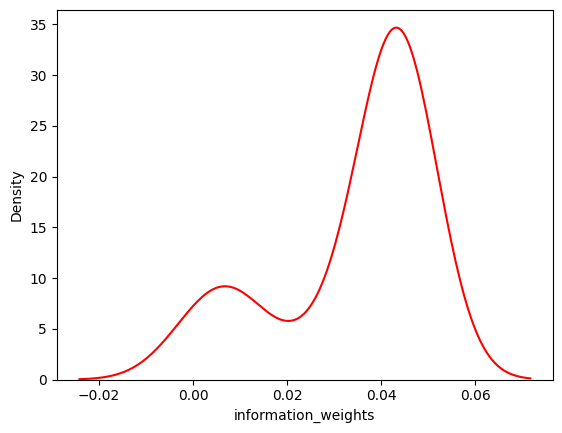

In [7]:
#ax = sns.histplot(df.information_weights, kde=True, stat="density")
sns.kdeplot(df.information_weights,  color="red")

 


In [8]:
df[df.information_weights < 0.01]

,coverage_alone,coverage_without,created_at,file,id,modified_at,msr_alone,msr_without,project,suite,test,test_id,coverage_impact,coverage_uniqueness,information_weights,mutants_killed_alone,mutants_killed_without,mutants_survived_alone,mutants_survived_without
0,0.265306,0.97449,2026-01-14 03:56:32.844719+00:00,tests/test_align.py,1,2026-02-19 01:32:40.708635+00:00,0.8985,0.1728,1,TestAlign,test_apply_transform_ccddata,tests/test_align.py::TestAlign::test_apply_tra...,0.0,0.0,0.009162,47,383,416,80
1,0.265306,0.97449,2026-01-14 03:56:32.851148+00:00,tests/test_align.py,2,2026-02-19 01:32:40.709298+00:00,0.8963,0.1771,1,TestAlign,test_apply_transform_nddata,tests/test_align.py::TestAlign::test_apply_tra...,0.0,0.0,0.009357,48,381,415,82
2,0.265306,0.97449,2026-01-14 03:56:32.853409+00:00,tests/test_align.py,3,2026-02-19 01:32:40.709650+00:00,0.8963,0.1490,1,TestAlign,test_apply_transform_npma,tests/test_align.py::TestAlign::test_apply_tra...,0.0,0.0,0.009357,48,394,415,69
7,0.183673,0.97449,2026-01-14 03:56:32.866119+00:00,tests/test_align.py,8,2026-02-19 01:32:40.711273+00:00,0.9222,0.1728,1,TestAlign,test_find_sources,tests/test_align.py::TestAlign::test_find_sources,0.0,0.0,0.007018,36,383,427,80
18,0.204082,0.97449,2026-01-14 03:56:32.891495+00:00,tests/test_align.py,19,2026-02-19 01:32:40.715038+00:00,1.0000,0.1771,1,TestFewSources,test_find_transform_twosources,tests/test_align.py::TestFewSources::test_find...,0.0,0.0,0.000000,0,381,463,82
23,0.265306,0.97449,2026-01-14 03:56:32.902990+00:00,tests/test_align.py,24,2026-02-19 01:32:40.716634+00:00,1.0000,0.1771,1,TestFewSources,test_register_twosources,tests/test_align.py::TestFewSources::test_regi...,0.0,0.0,0.000000,0,381,463,82


<Axes: xlabel='information_weights', ylabel='mutants_killed_without'>

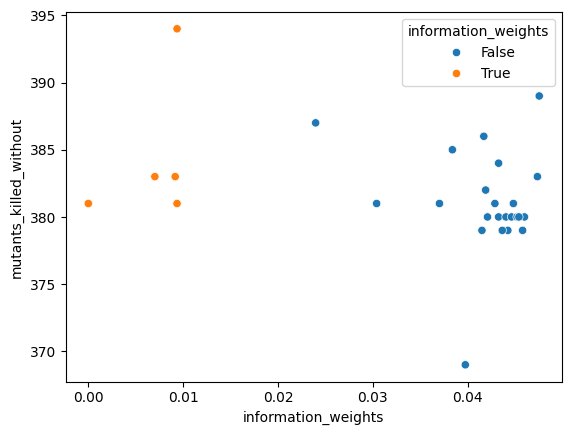

In [10]:
sns.scatterplot(data=df, x="information_weights", y="mutants_killed_without", hue=(df.information_weights < 0.01))

In [11]:
tests_number = proj.store.count_tests()


tests_number

29

In [26]:
ORDERING_METHOD = "mutants_killed_without"
ASCENDING = True
DROP_COLS = ["tests_ids", "created_at"]
columns = ['msr', 'tests_count',  
       'information_weights', 'mutants_killed', 'mutants_survived']
edf = proj.store.get_entropy_dataframe(ordering_method=ORDERING_METHOD, ascending=ASCENDING)
edf[columns]

/home/juan/misc/proyectos/yagua/src/yagua/dal/project_store.py:473: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.msr.replace(np.nan, None, inplace=True)


,msr,tests_count,information_weights,mutants_killed,mutants_survived
0,0.5594,1,0.021149,204,259
1,0.4471,2,0.026539,256,207
2,0.3823,3,0.029650,286,177
3,0.3737,4,0.030064,290,173
4,0.3477,5,0.031308,302,161
5,0.3499,6,0.031205,301,162
6,0.3456,7,0.031412,303,160
7,0.3456,8,0.031412,303,160
8,0.3456,9,0.031412,303,160
9,0.3283,10,0.032241,311,152


<Axes: xlabel='tests_count', ylabel='mutants_survived'>

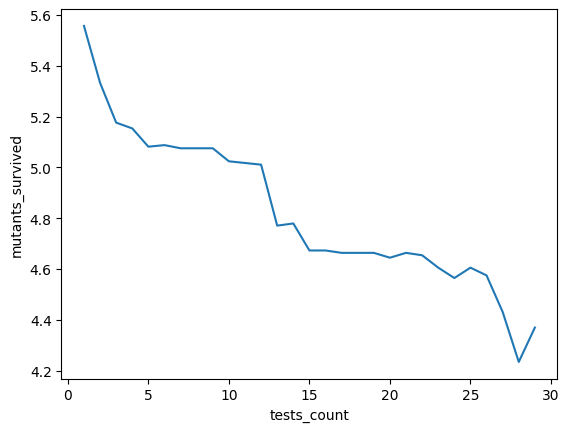

In [25]:
sns.lineplot(data=edf, x="tests_count", y=np.log(edf.mutants_survived))

<Axes: xlabel='tests_count', ylabel='msr'>

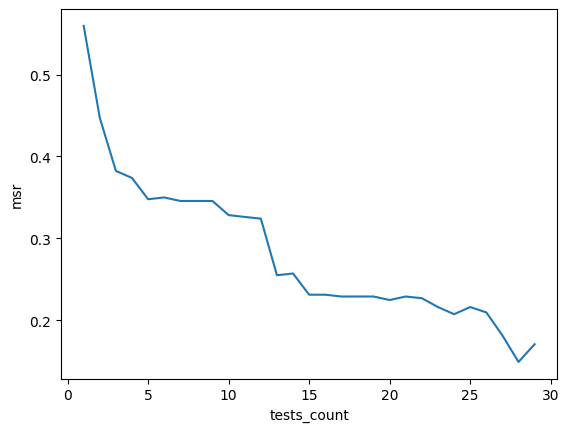

In [27]:
sns.lineplot(data=edf, x="tests_count", y="msr")

In [33]:
import hashlib

def hashs(tests_ids):
    all_ids = "".join(sorted(tests_ids))
    md5 = hashlib.md5(all_ids.encode("utf8"))
    coso = md5.hexdigest()
    return f"get_survival_rate_for_tests_{coso}.sqlite"

edf["crayconf"] = edf.tests_ids.apply(hashs)

29

In [113]:
import sh
folder = "/home/juan/misc/proyectos/yagua/src/_yagua_wd_astroalign_/yagua_cray"
test_total = proj.store.count_tests()

def get_crayconf_path(tests_count):
    coso = edf[edf.tests_count == tests_count]["crayconf"].tolist()[0]
    return f"{folder}/{coso}"

def outcomes(tests_count):
    if tests_count == test_total:
        path = f"{folder}/get_survival_rate.sqlite"
    else:
        path = get_crayconf_path(tests_count)
    with sqlite3.connect(path) as conn:
        df = pd.read_sql('select * from work_results', conn)
    the_outcomes = df.test_outcome.where(df.output != "timeout", "TIMEOUT")
    od = dict(sorted(the_outcomes.value_counts().to_dict().items()))
    return od.get("TIMEOUT", 0.) 

In [114]:
proj.store.mutants_number

463

In [116]:
rows = []
for _, row in edf.iterrows():
    
    tc = row.tests_count
    row = {
        "Tests": tc,
        "Mutants Survived": row.mutants_survived,
        "Timeout": outcomes(tc)
    }
    rows.append(row)

toplot = pd.DataFrame(rows)
toplot

,Tests,Mutants Survived,Timeout
0,1,259,0.0
1,2,207,0.0
2,3,177,0.0
3,4,173,0.0
4,5,161,0.0
5,6,162,0.0
6,7,160,0.0
7,8,160,0.0
8,9,160,1.0
9,10,152,1.0


In [117]:
import seaborn as sns
import matplotlib.pyplot as plt

df = toplot
sns.lineplot(
    data=df,
    x="Tests",
    y="Mutants Survived",
)

plt.errorbar(
    x=df["Tests"],
    y=df["Mutants Survived"],
    yerr=df["Timeout"],
    fmt='none',
    capsize=4,
    color='steelblue'
)

plt.show() pd

SyntaxError: invalid syntax (1593220437.py, line 20)

In [59]:
pd.read_sql?

Signature:
pd.read_sql(
    sql,
    con,
    index_col: 'str | list[str] | None' = None,
    coerce_float: 'bool' = True,
    params=None,
    parse_dates=None,
    columns: 'list[str] | None' = None,
    chunksize: 'int | None' = None,
    dtype_backend: 'DtypeBackend | lib.NoDefault' = <no_default>,
    dtype: 'DtypeArg | None' = None,
) -> 'DataFrame | Iterator[DataFrame]'
Docstring:
Read SQL query or database table into a DataFrame.

This function is a convenience wrapper around ``read_sql_table`` and
``read_sql_query`` (for backward compatibility). It will delegate
to the specific function depending on the provided input. A SQL query
will be routed to ``read_sql_query``, while a database table name will
be routed to ``read_sql_table``. Note that the delegated function might
have more specific notes about their functionality not listed here.

Parameters
----------
sql : str or SQLAlchemy Selectable (select or text object)
    SQL query to be executed or a table name.
con : ADBC Co